<a href="https://colab.research.google.com/github/sudip328/Random-Forest-Cs2GeX6-/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:


,Compound,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy,Band_gap
0,Cs2GeF6,9.23,786.86,1.14,0.398,-4.78,5.910
1,Cs2GeCl6,10.59,1187.00,1.05,0.293,-3.38,2.260
2,Cs2GeBr6,11.09,1365.11,1.03,0.271,-2.72,1.016
3,Cs2GeI6,11.70,1601.50,1.00,0.241,-1.03,0.000



Feature matrix shape: (4, 5)
Target shape: (4,)

       LINEAR REGRESSION RESULTS

TRAINING PERFORMANCE
RMSE = 0.0000 eV
MAE  = 0.0000 eV
R²   = 1.0000

PREDICTION RESULTS


,Compound,Actual_Band_Gap,Predicted_Band_Gap,Absolute_Error
0,Cs2GeF6,5.910,5.910000e+00,4.973799e-13
1,Cs2GeCl6,2.260,2.260000e+00,7.638334e-14
2,Cs2GeBr6,1.016,1.016000e+00,2.113865e-13
3,Cs2GeI6,0.000,2.486900e-13,2.486900e-13



LINEAR REGRESSION COEFFICIENTS


,Feature,Coefficient
0,Lattice_parameter,-3.122119
1,Volume,-0.000202
2,Tolerance_factor,0.603268
3,Octahedral_factor,0.741675
4,Formation_energy,0.577817



Intercept = 36.664892733307404

LINEAR REGRESSION EQUATION
Band Gap = 36.664893
-3.122119 × Lattice_parameter
-0.000202 × Volume
+0.603268 × Tolerance_factor
+0.741675 × Octahedral_factor
+0.577817 × Formation_energy

       LOOCV PERFORMANCE
RMSE = 0.4646 eV
MAE  = 0.4090 eV
R²   = 0.9568

LOOCV PREDICTIONS


,Compound,Actual_Band_Gap,LOOCV_Predicted_Band_Gap,Absolute_Error
0,Cs2GeF6,5.910,5.130955,0.779045
1,Cs2GeCl6,2.260,2.479435,0.219435
2,Cs2GeBr6,1.016,0.747879,0.268121
3,Cs2GeI6,0.000,0.369266,0.369266



TRAINING VS LOOCV


,Metric,Training,LOOCV
0,RMSE (eV),2.998967e-13,0.464572
1,MAE (eV),2.584599e-13,0.408967
2,R²,1.000000e+00,0.956775


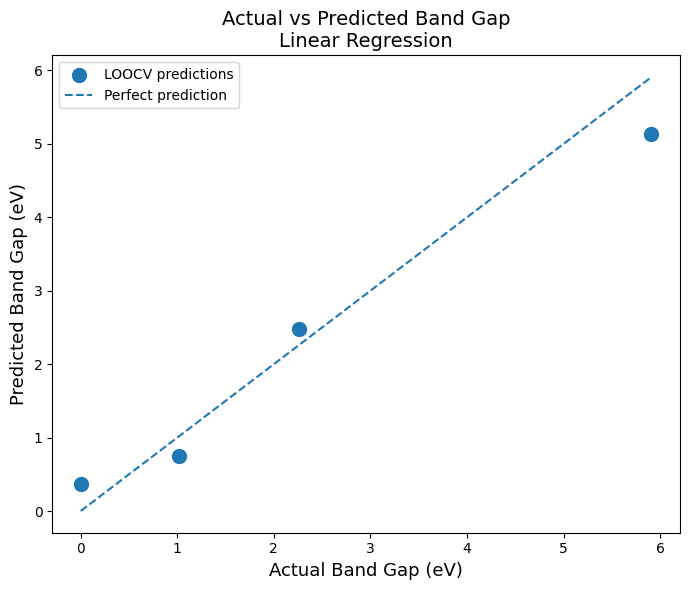

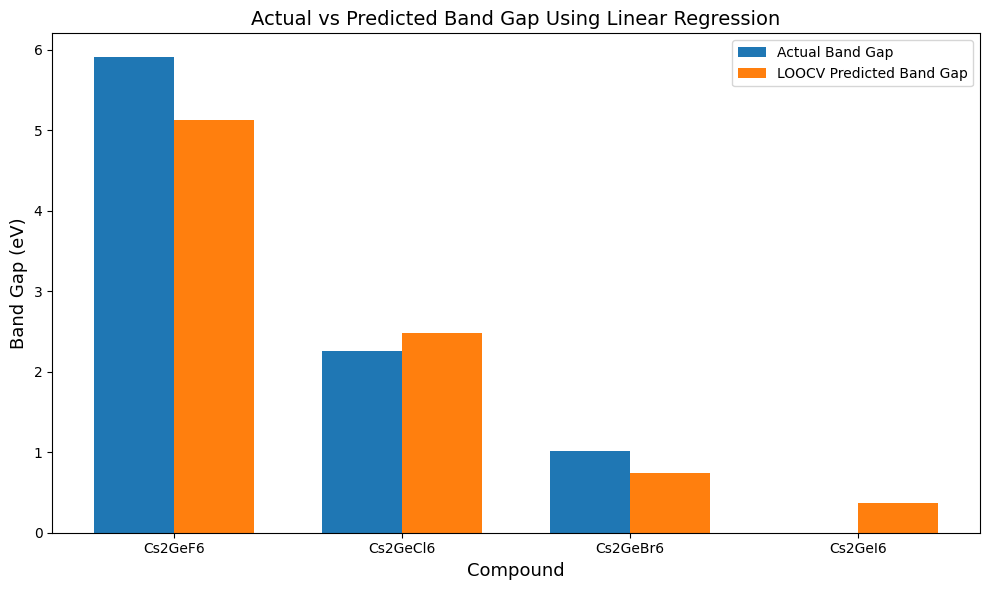

In [1]:
# ============================================================
# LINEAR REGRESSION BAND GAP PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ============================================================
# 1. DATA
# ============================================================

data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
display(df)

# ============================================================
# 2. FEATURES AND TARGET
# ============================================================

features = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

X = df[features]
y = df["Band_gap"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# ============================================================
# 3. LINEAR REGRESSION MODEL
# ============================================================

linear_model = LinearRegression()

# Fit the model
linear_model.fit(X, y)

# ============================================================
# 4. TRAINING PREDICTIONS
# ============================================================

y_pred = linear_model.predict(X)

# ============================================================
# 5. TRAINING PERFORMANCE
# ============================================================

train_rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

train_mae = mean_absolute_error(
    y, y_pred
)

train_r2 = r2_score(
    y, y_pred
)

print("\n" + "=" * 55)
print("       LINEAR REGRESSION RESULTS")
print("=" * 55)

print("\nTRAINING PERFORMANCE")
print(f"RMSE = {train_rmse:.4f} eV")
print(f"MAE  = {train_mae:.4f} eV")
print(f"R²   = {train_r2:.4f}")

# ============================================================
# 6. PREDICTION RESULTS
# ============================================================

results = pd.DataFrame({
    "Compound": df["Compound"],
    "Actual_Band_Gap": y,
    "Predicted_Band_Gap": y_pred
})

results["Absolute_Error"] = abs(
    results["Actual_Band_Gap"] -
    results["Predicted_Band_Gap"]
)

print("\nPREDICTION RESULTS")
display(results)

# ============================================================
# 7. LINEAR REGRESSION COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

print("\nLINEAR REGRESSION COEFFICIENTS")
display(coefficients)

print(
    "\nIntercept =",
    linear_model.intercept_
)

# ============================================================
# 8. LINEAR REGRESSION EQUATION
# ============================================================

print("\nLINEAR REGRESSION EQUATION")
print("Band Gap = {:.6f}".format(linear_model.intercept_))

for feature, coefficient in zip(
    features,
    linear_model.coef_
):
    print(
        "{:+.6f} × {}".format(
            coefficient,
            feature
        )
    )

# ============================================================
# 9. LEAVE-ONE-OUT CROSS VALIDATION
# ============================================================

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Create a new Linear Regression model
    linear_loo = LinearRegression()

    # Fit only on training data
    linear_loo.fit(
        X_train,
        y_train
    )

    # Predict the left-out compound
    prediction = linear_loo.predict(
        X_test
    )

    loo_predictions.append(
        prediction[0]
    )

    loo_actual.append(
        y_test.iloc[0]
    )

    loo_compounds.append(
        df["Compound"].iloc[test_index[0]]
    )

# ============================================================
# 10. LOOCV PERFORMANCE
# ============================================================

loo_rmse = np.sqrt(
    mean_squared_error(
        loo_actual,
        loo_predictions
    )
)

loo_mae = mean_absolute_error(
    loo_actual,
    loo_predictions
)

loo_r2 = r2_score(
    loo_actual,
    loo_predictions
)

print("\n" + "=" * 55)
print("       LOOCV PERFORMANCE")
print("=" * 55)

print(f"RMSE = {loo_rmse:.4f} eV")
print(f"MAE  = {loo_mae:.4f} eV")
print(f"R²   = {loo_r2:.4f}")

# ============================================================
# 11. LOOCV RESULTS
# ============================================================

loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

loo_results["Absolute_Error"] = abs(
    loo_results["Actual_Band_Gap"] -
    loo_results["LOOCV_Predicted_Band_Gap"]
)

print("\nLOOCV PREDICTIONS")
display(loo_results)

# ============================================================
# 12. TRAINING VS LOOCV
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "RMSE (eV)",
        "MAE (eV)",
        "R²"
    ],

    "Training": [
        train_rmse,
        train_mae,
        train_r2
    ],

    "LOOCV": [
        loo_rmse,
        loo_mae,
        loo_r2
    ]
})

print("\nTRAINING VS LOOCV")
display(comparison)

# ============================================================
# 13. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    loo_actual,
    loo_predictions,
    s=100,
    label="LOOCV predictions"
)

# Perfect prediction line
min_value = min(
    min(loo_actual),
    min(loo_predictions)
)

max_value = max(
    max(loo_actual),
    max(loo_predictions)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel(
    "Actual Band Gap (eV)",
    fontsize=13
)

plt.ylabel(
    "Predicted Band Gap (eV)",
    fontsize=13
)

plt.title(
    "Actual vs Predicted Band Gap\nLinear Regression",
    fontsize=14
)

plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 14. ACTUAL VS PREDICTED FOR EACH COMPOUND
# ============================================================

x = np.arange(len(loo_compounds))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    loo_actual,
    width,
    label="Actual Band Gap"
)

plt.bar(
    x + width/2,
    loo_predictions,
    width,
    label="LOOCV Predicted Band Gap"
)

plt.xlabel(
    "Compound",
    fontsize=13
)

plt.ylabel(
    "Band Gap (eV)",
    fontsize=13
)

plt.title(
    "Actual vs Predicted Band Gap Using Linear Regression",
    fontsize=14
)

plt.xticks(
    x,
    loo_compounds
)

plt.legend()
plt.tight_layout()
plt.show()